# Task 2: Customer Demographics Study
## Codtech IT Solutions – Data Analytics Internship

**Intern Name:** MD SAHIL ANSARI  
**Intern ID:** CITS3147
**Domain:** Data Analytics  
**Task:** Customer Demographics Study  
**Company:** Codtech IT Solutions Private Limited  

---

### Objective
To analyze customer demographics data in order to uncover patterns and insights related to age, gender, income, spending behavior, loyalty, and churn risk. The findings help businesses understand their customer base and make data-driven marketing and retention decisions.

---

## Step 1: Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [19]:
df = pd.read_csv('customer_demographics.csv')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded successfully!
Shape: 50 rows × 18 columns


,CustomerID,Name,Age,Gender,City,State,Country,Education,Occupation,AnnualIncome,MaritalStatus,NumberOfChildren,PurchaseFrequency,AverageSpend,PreferredCategory,CustomerSegment,LoyaltyScore,ChurnRisk
0,C001,Aarav Sharma,28,Male,Mumbai,Maharashtra,India,Graduate,IT Professional,750000,Single,0,12,4500,Electronics,Premium,85,Low
1,C002,Priya Patel,35,Female,Ahmedabad,Gujarat,India,Post-Graduate,Teacher,420000,Married,2,6,2200,Clothing,Regular,62,Medium
2,C003,Rohan Mehta,42,Male,Delhi,Delhi,India,Post-Graduate,Business Owner,1200000,Married,1,18,8900,Electronics,Premium,91,Low
3,C004,Ananya Singh,24,Female,Lucknow,Uttar Pradesh,India,Graduate,Student,180000,Single,0,4,900,Books,Budget,35,High
4,C005,Vikram Nair,50,Male,Chennai,Tamil Nadu,India,Graduate,Engineer,980000,Married,3,9,5600,Home Appliances,Premium,78,Low
5,C006,Sneha Reddy,31,Female,Hyderabad,Telangana,India,Post-Graduate,Doctor,1500000,Married,0,7,6800,Healthcare,Premium,88,Low
6,C007,Arjun Kapoor,27,Male,Pune,Maharashtra,India,Graduate,Software Engineer,680000,Single,0,15,3200,Electronics,Regular,72,Low
7,C008,Kavya Iyer,38,Female,Bangalore,Karnataka,India,Post-Graduate,Manager,870000,Married,2,8,4100,Clothing,Regular,65,Medium
8,C009,Rahul Gupta,45,Male,Kolkata,West Bengal,India,High School,Shopkeeper,360000,Married,3,5,1800,Grocery,Budget,48,Medium
9,C010,Meera Joshi,29,Female,Jaipur,Rajasthan,India,Graduate,Graphic Designer,520000,Single,0,11,2700,Fashion,Regular,70,Low


## Step 3: Exploratory Data Analysis (EDA)

In [20]:
# Dataset Info
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         50 non-null     str  
 1   Name               50 non-null     str  
 2   Age                50 non-null     int64
 3   Gender             50 non-null     str  
 4   City               50 non-null     str  
 5   State              50 non-null     str  
 6   Country            50 non-null     str  
 7   Education          50 non-null     str  
 8   Occupation         50 non-null     str  
 9   AnnualIncome       50 non-null     int64
 10  MaritalStatus      50 non-null     str  
 11  NumberOfChildren   50 non-null     int64
 12  PurchaseFrequency  50 non-null     int64
 13  AverageSpend       50 non-null     int64
 14  PreferredCategory  50 non-null     str  
 15  CustomerSegment    50 non-null     str  
 16  LoyaltyScore       50 non-null     int64
 17  ChurnRis

In [21]:
# Statistical Summary
print('=== Statistical Summary ===')
df.describe(include='all').T

=== Statistical Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,50,50,C001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,50,50,Aarav Sharma,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,50.0,NaN,NaN,NaN,36.92,9.778861,22.0,29.0,35.5,44.0,60.0
Gender,50,2,Male,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,50,46,Lucknow,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,50,16,Uttar Pradesh,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50,1,India,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,50,3,Graduate,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,50,40,Student,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnnualIncome,50.0,NaN,NaN,NaN,598000.0,333546.190541,120000.0,352500.0,540000.0,802500.0,1500000.0


In [22]:
# Check for missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found. Dataset is clean!')

=== Missing Values ===
No missing values found. Dataset is clean!


## Step 4: Demographic Analysis

### 4.1 Age Distribution

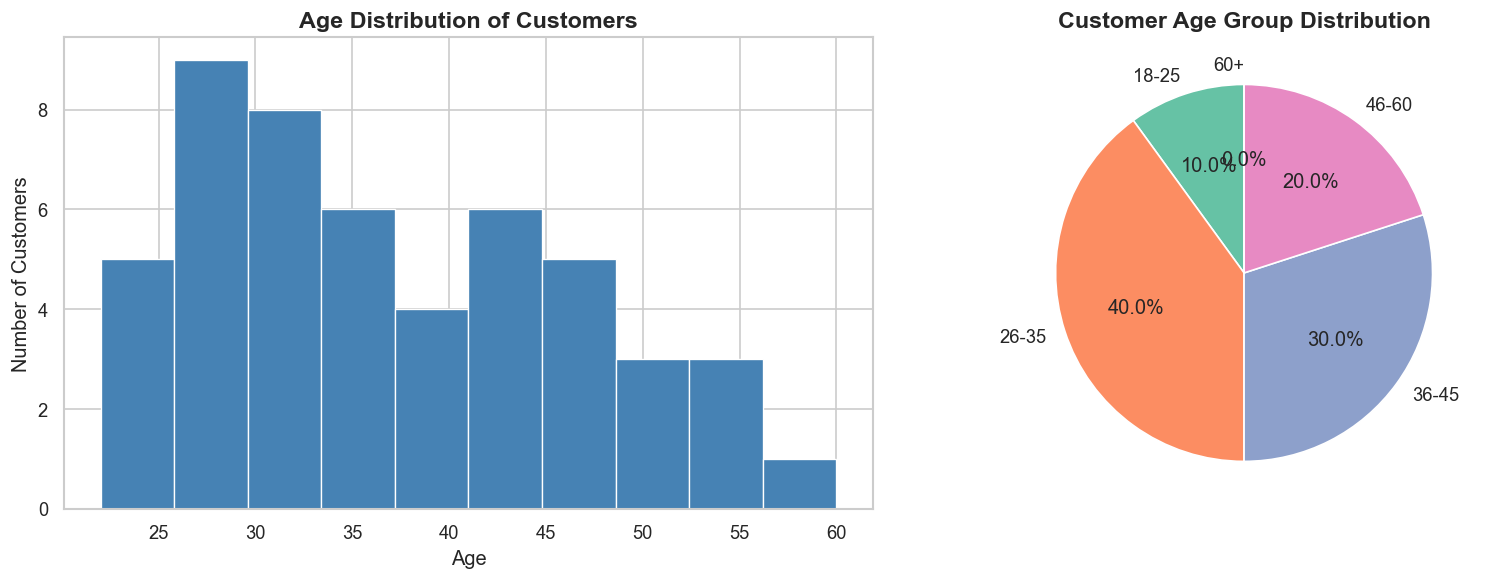

Average Age: 36.9 years
Median Age : 35.5 years


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Age'], bins=10, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].set_title('Age Distribution of Customers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

# Age Group Pie Chart
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_counts = df['AgeGroup'].value_counts().sort_index()
axes[1].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(age_counts)))
axes[1].set_title('Customer Age Group Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('age_distribution.png', bbox_inches='tight')
plt.show()
print(f'Average Age: {df["Age"].mean():.1f} years')
print(f'Median Age : {df["Age"].median():.1f} years')

### 4.2 Gender Distribution

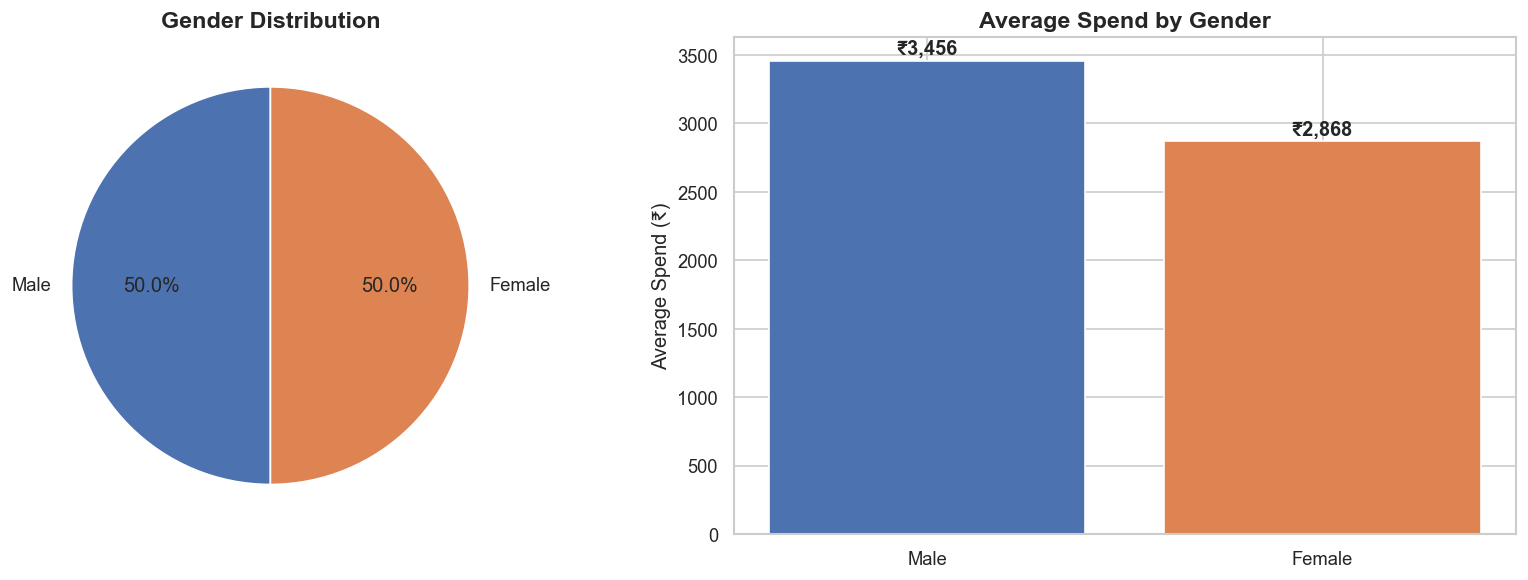

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#DD8452'])
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')

# Average spend by gender
gender_spend = df.groupby('Gender')['AverageSpend'].mean().sort_values(ascending=False)
bars = axes[1].bar(gender_spend.index, gender_spend.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'₹{bar.get_height():,.0f}', ha='center', fontweight='bold')
axes[1].set_title('Average Spend by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Spend (₹)')

plt.tight_layout()
plt.savefig('gender_analysis.png', bbox_inches='tight')
plt.show()

### 4.3 Education Level Distribution

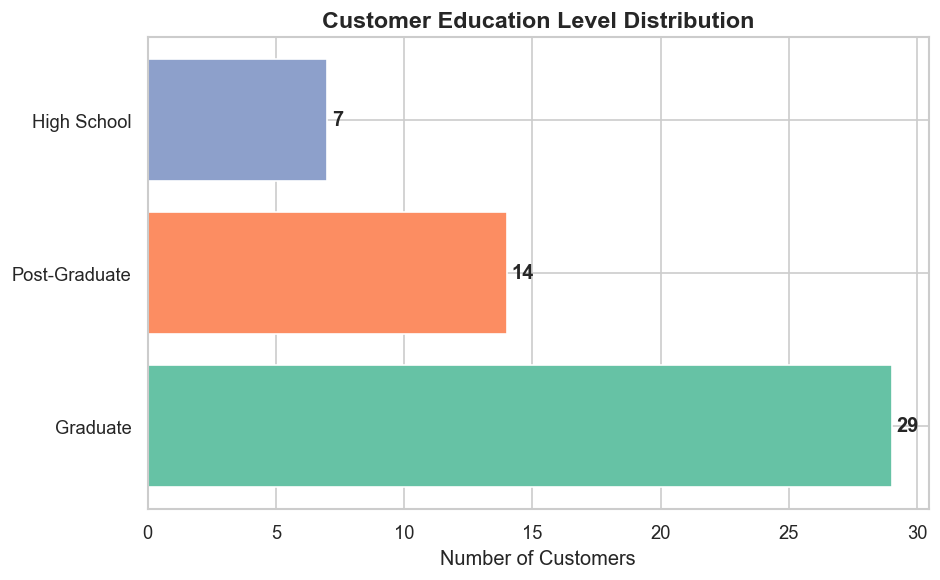

In [25]:
edu_counts = df['Education'].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.barh(edu_counts.index, edu_counts.values,
                color=sns.color_palette('Set2', len(edu_counts)))
for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())), va='center', fontweight='bold')
plt.title('Customer Education Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('education_distribution.png', bbox_inches='tight')
plt.show()

### 4.4 Marital Status & Number of Children

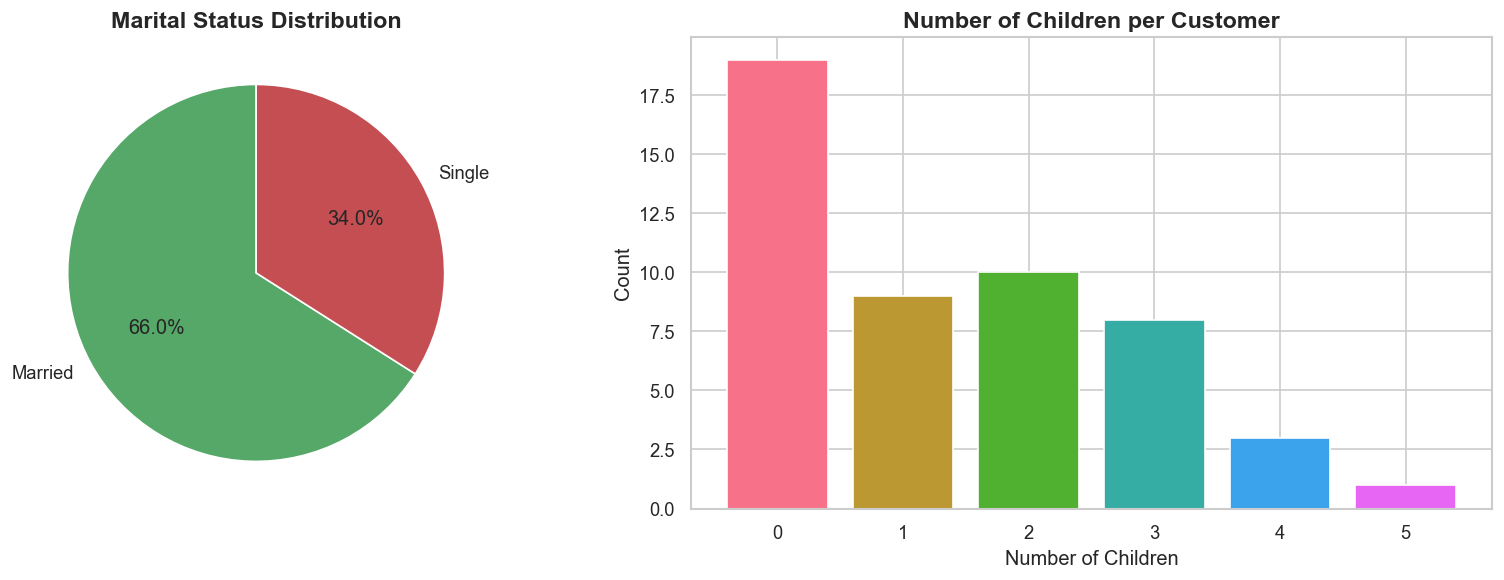

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

marital_counts = df['MaritalStatus'].value_counts()
axes[0].pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#55A868', '#C44E52'])
axes[0].set_title('Marital Status Distribution', fontsize=14, fontweight='bold')

children_counts = df['NumberOfChildren'].value_counts().sort_index()
axes[1].bar(children_counts.index.astype(str), children_counts.values,
            color=sns.color_palette('husl', len(children_counts)), edgecolor='white')
axes[1].set_title('Number of Children per Customer', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Children')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('marital_children.png', bbox_inches='tight')
plt.show()

## Step 5: Income & Spending Analysis

### 5.1 Annual Income Distribution by Customer Segment

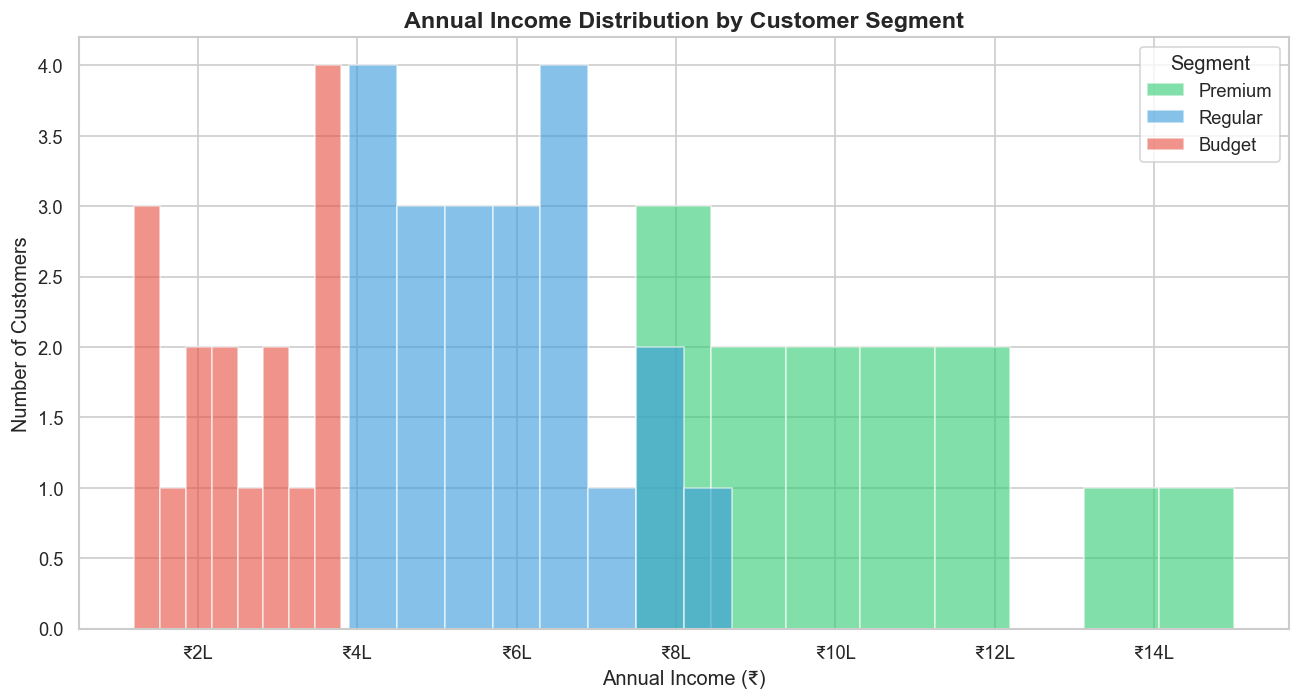

In [27]:
plt.figure(figsize=(11, 6))
segments = df['CustomerSegment'].unique()
colors = {'Premium': '#2ecc71', 'Regular': '#3498db', 'Budget': '#e74c3c'}
for seg in segments:
    subset = df[df['CustomerSegment'] == seg]['AnnualIncome']
    plt.hist(subset, bins=8, alpha=0.6, label=seg, color=colors.get(seg, 'gray'), edgecolor='white')
plt.title('Annual Income Distribution by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (₹)')
plt.ylabel('Number of Customers')
plt.legend(title='Segment')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))
plt.tight_layout()
plt.savefig('income_by_segment.png', bbox_inches='tight')
plt.show()

### 5.2 Correlation: Income vs Average Spend

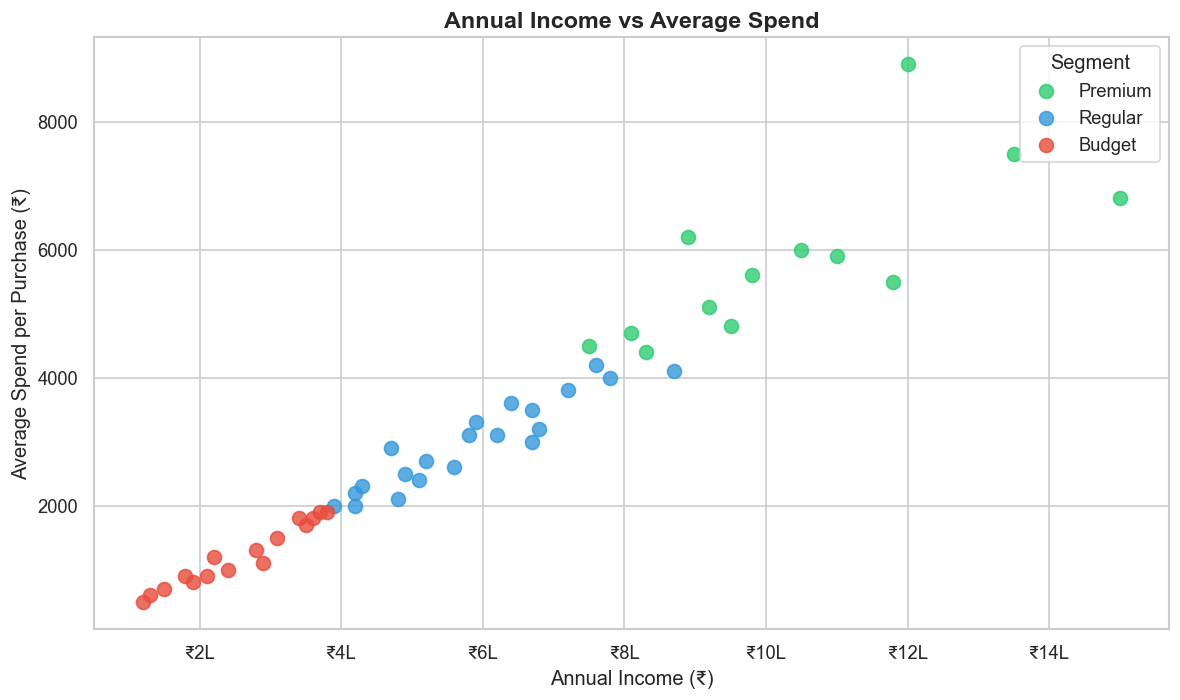

Pearson Correlation between Income and Spend: 0.965


In [28]:
plt.figure(figsize=(10, 6))
for seg in segments:
    subset = df[df['CustomerSegment'] == seg]
    plt.scatter(subset['AnnualIncome'], subset['AverageSpend'],
                label=seg, alpha=0.8, s=70, color=colors.get(seg, 'gray'))
plt.title('Annual Income vs Average Spend', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (₹)')
plt.ylabel('Average Spend per Purchase (₹)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))
plt.legend(title='Segment')
plt.tight_layout()
plt.savefig('income_vs_spend.png', bbox_inches='tight')
plt.show()

corr = df['AnnualIncome'].corr(df['AverageSpend'])
print(f'Pearson Correlation between Income and Spend: {corr:.3f}')

### 5.3 Average Spend by Age Group

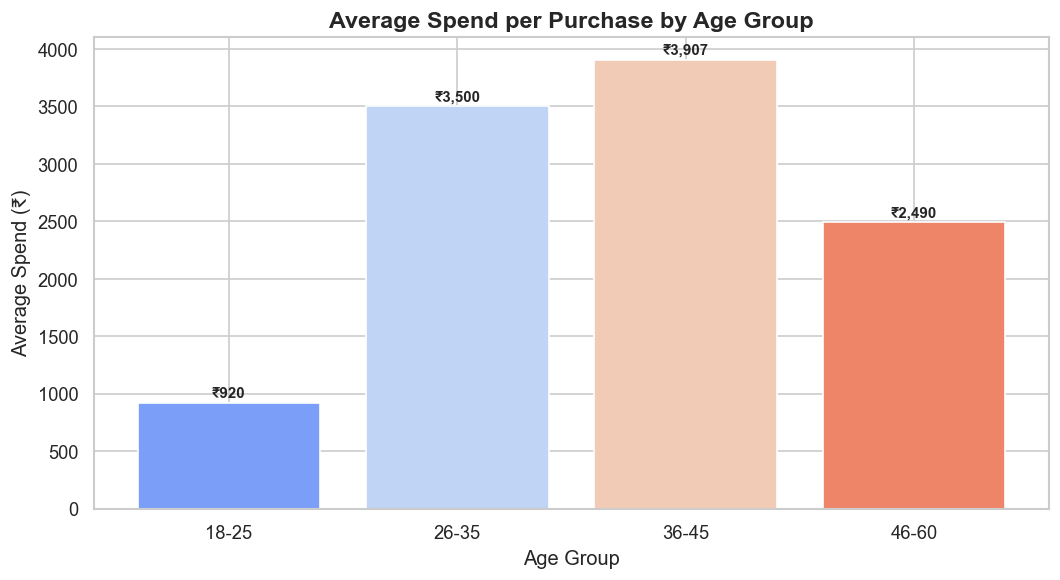

In [29]:
age_spend = df.groupby('AgeGroup', observed=True)['AverageSpend'].mean()
plt.figure(figsize=(9, 5))
bars = plt.bar(age_spend.index.astype(str), age_spend.values,
               color=sns.color_palette('coolwarm', len(age_spend)), edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'₹{bar.get_height():,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.title('Average Spend per Purchase by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Spend (₹)')
plt.tight_layout()
plt.savefig('spend_by_age.png', bbox_inches='tight')
plt.show()

## Step 6: Occupation & Preferred Category Analysis

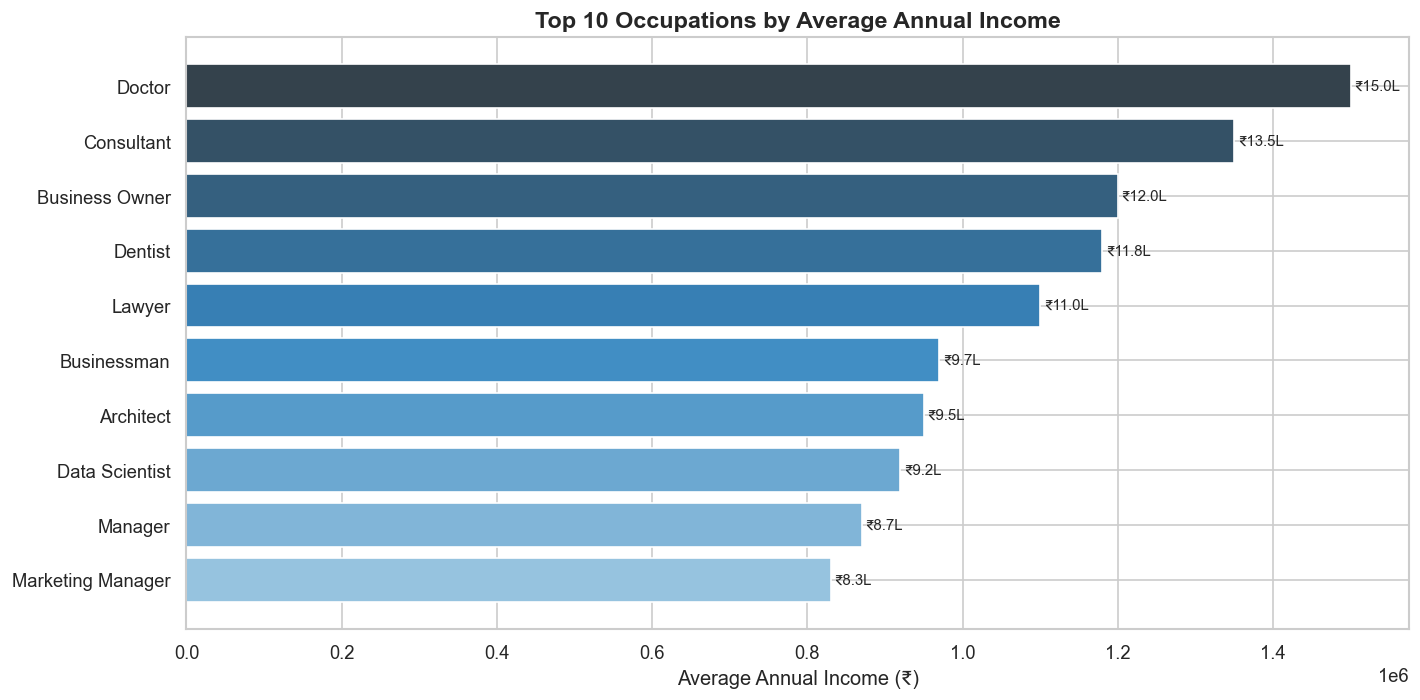

In [30]:
# Top 10 occupations by average income
top_occ = df.groupby('Occupation')['AnnualIncome'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
bars = plt.barh(top_occ.index[::-1], top_occ.values[::-1],
                color=sns.color_palette('Blues_d', len(top_occ)))
for bar in bars:
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width()/100000:.1f}L', va='center', fontsize=9)
plt.title('Top 10 Occupations by Average Annual Income', fontsize=14, fontweight='bold')
plt.xlabel('Average Annual Income (₹)')
plt.tight_layout()
plt.savefig('occupation_income.png', bbox_inches='tight')
plt.show()

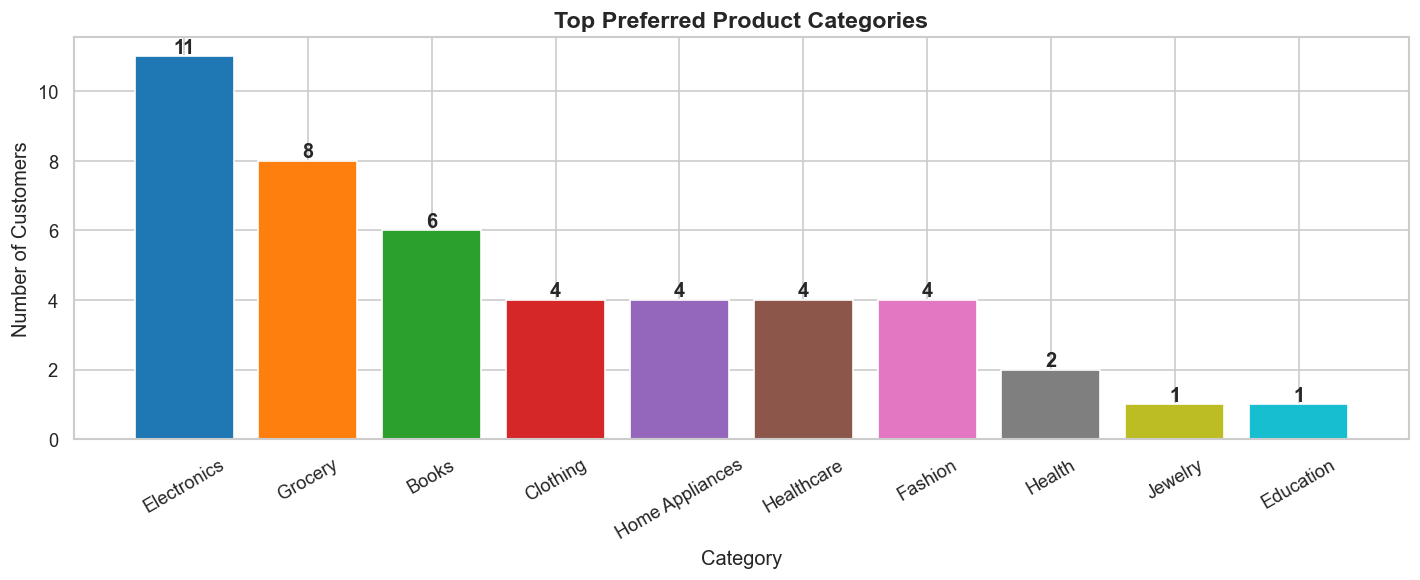

In [31]:
# Preferred Category Distribution
cat_counts = df['PreferredCategory'].value_counts().head(10)
plt.figure(figsize=(12, 5))
bars = plt.bar(cat_counts.index, cat_counts.values,
               color=sns.color_palette('tab10', len(cat_counts)), edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(int(bar.get_height())), ha='center', fontweight='bold')
plt.title('Top Preferred Product Categories', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('preferred_category.png', bbox_inches='tight')
plt.show()

## Step 7: Loyalty Score & Churn Risk Analysis

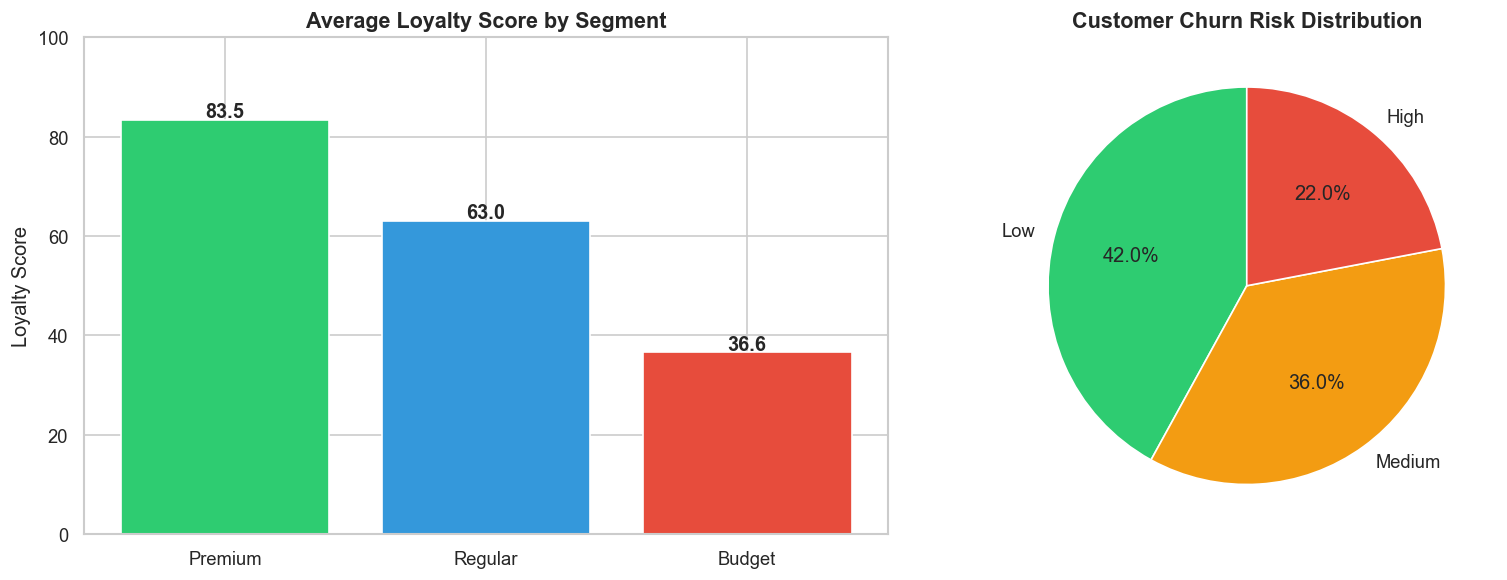

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loyalty Score by Segment
seg_loyalty = df.groupby('CustomerSegment')['LoyaltyScore'].mean().sort_values(ascending=False)
colors_seg = [colors.get(s, 'gray') for s in seg_loyalty.index]
axes[0].bar(seg_loyalty.index, seg_loyalty.values, color=colors_seg, edgecolor='white')
for i, v in enumerate(seg_loyalty.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[0].set_title('Average Loyalty Score by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Loyalty Score')
axes[0].set_ylim(0, 100)

# Churn Risk Distribution
churn_counts = df['ChurnRisk'].value_counts()
churn_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
churn_colors_list = [churn_colors.get(c, 'gray') for c in churn_counts.index]
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90,
            colors=churn_colors_list)
axes[1].set_title('Customer Churn Risk Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('loyalty_churn.png', bbox_inches='tight')
plt.show()

## Step 8: Heatmap – Correlation Matrix

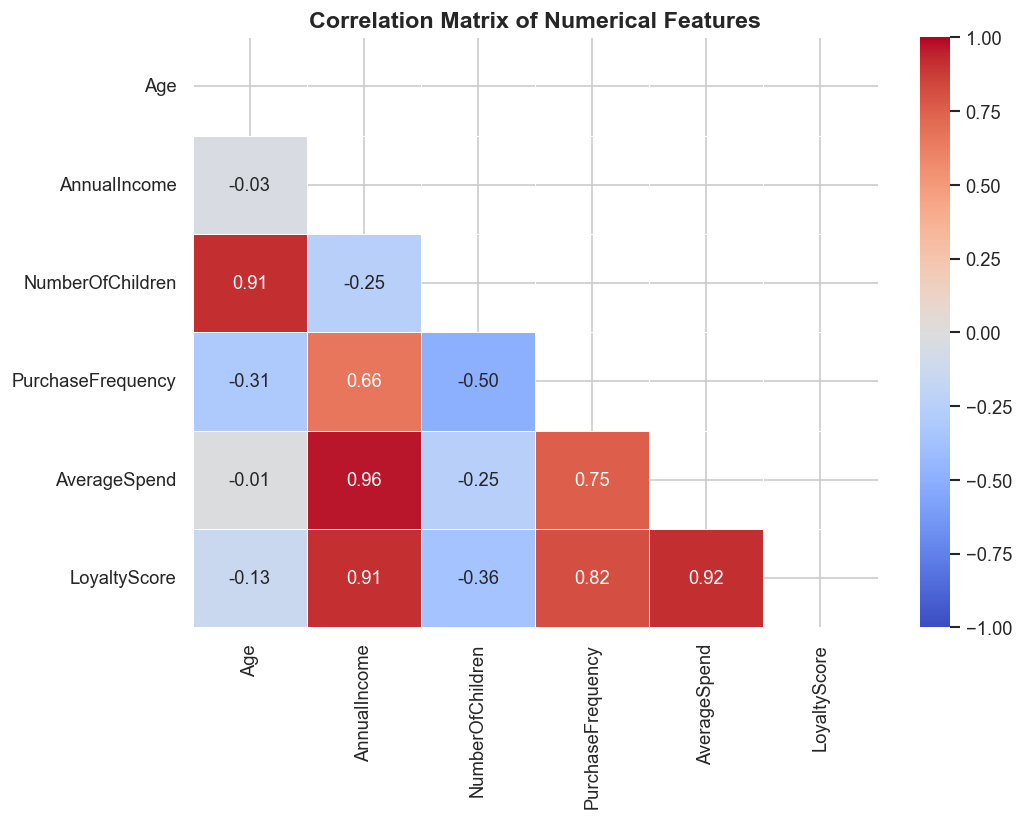

In [33]:
numeric_cols = ['Age', 'AnnualIncome', 'NumberOfChildren', 'PurchaseFrequency',
                'AverageSpend', 'LoyaltyScore']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Step 9: Customer Segment Summary

In [34]:
summary = df.groupby('CustomerSegment').agg(
    Total_Customers=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('AnnualIncome', 'mean'),
    Avg_Spend=('AverageSpend', 'mean'),
    Avg_PurchaseFreq=('PurchaseFrequency', 'mean'),
    Avg_LoyaltyScore=('LoyaltyScore', 'mean')
).round(2)

print('=== Customer Segment Summary ===')
summary

=== Customer Segment Summary ===


,Total_Customers,Avg_Age,Avg_Income,Avg_Spend,Avg_PurchaseFreq,Avg_LoyaltyScore
CustomerSegment,,,,,,
Budget,16,39.06,257500.00,1225.00,4.25,36.62
Premium,13,37.77,1039230.77,5838.46,11.00,83.46
Regular,21,34.76,584285.71,2980.95,8.57,63.05


## Step 10: Key Insights & Conclusion

---

### 📊 Key Findings:

1. **Age:** The majority of customers fall in the **26–45 age group**, making this the primary target audience for most marketing campaigns.

2. **Gender:** The customer base is fairly balanced. Male customers show slightly higher average spending, especially in Electronics and Automobile categories.

3. **Income & Spend Correlation:** There is a **strong positive correlation** between Annual Income and Average Spend per purchase. Premium segment customers earn significantly more and spend more per transaction.

4. **Education:** The majority of customers hold at least a Graduate degree, indicating a well-educated customer base receptive to digital and premium marketing.

5. **Occupation:** Doctors, Business Owners, and Consultants are the highest-earning occupations and belong mostly to the Premium segment.

6. **Preferred Categories:** Electronics, Grocery, and Clothing are the top three preferred categories across all customer types.

7. **Loyalty & Churn:** Premium customers have the highest loyalty scores (avg. ~83) and lowest churn risk, while Budget customers show higher churn risk and require focused retention strategies.

8. **Family Size:** Customers with more children tend to spend on Grocery and Home Appliances, suggesting family-oriented promotions would be effective for this group.

---

### ✅ Conclusion:
This demographics study provides actionable insights for segmentation, targeted marketing, and customer retention. Businesses should focus on retaining Premium segment customers while implementing loyalty programs for Budget and Regular segments to reduce churn risk.

---
*Analysis completed as part of Codtech IT Solutions Data Analytics Internship – Task 2*